# Comparaison des modèles de consommation électrique

Ce notebook explique les étapes suivies afin de sélectionner l'algorithme de machine learnin le plus adapté à notre besoin dans le cadre du projet EnerVision

Synthèse pour short list d'algo :

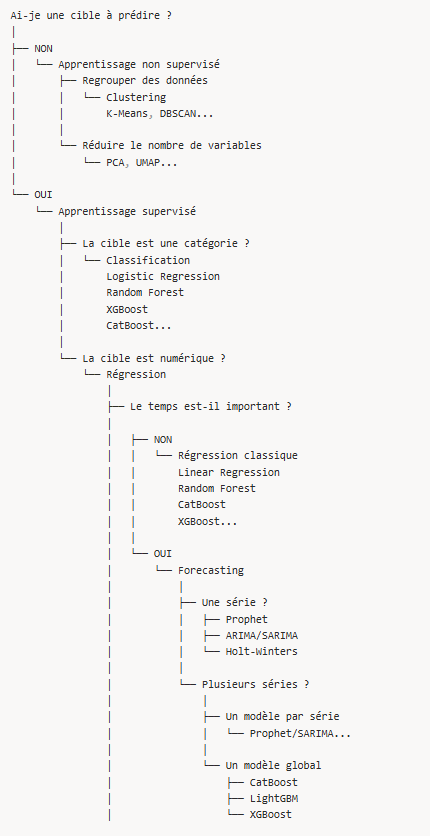

Après cette première analyse, deux approches ressortaient particulièrement.

Prophet est un algorithme spécialisé dans le forecasting de séries temporelles. Il apprend directement à partir de l’historique les tendances et les saisonnalités, par exemple journalières, hebdomadaires ou annuelles. Il est particulièrement adapté lorsqu’on travaille sur une série temporelle donnée, mais il est moins naturel dans notre cas où l’on souhaite disposer d’un modèle global capable de gérer plusieurs sites très différents.

CatBoost est un algorithme de Gradient Boosting basé sur des arbres de décision. Contrairement à Prophet, il ne comprend pas directement la dimension temporelle : celle-ci doit être transformée en features comme l’heure, le jour de la semaine, les lags ou les moyennes glissantes. En revanche, il permet d’entraîner un modèle global sur l’ensemble des sites.

Parmi les principales implémentations de Gradient Boosting — CatBoost, LightGBM et XGBoost — CatBoost était particulièrement intéressant pour notre cas car il permet de gérer nativement les variables catégorielles comme site_id et site_type.

## 1. Importer les bibliothèques

On importe les outils utilisés pour préparer les données, entraîner les modèles et calculer les erreurs.

In [1]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 2. Charger et découvrir les données

On charge le fichier puis on vérifie sa taille, ses colonnes et ses valeurs manquantes.

In [2]:
raw_data = pd.read_csv("../datas/all_sites_combined.csv")
raw_data.head()

,timestamp,site_id,site_type,site_name,consumption_kwh,consumption_euros,temperature_celsius,humidity_percent,solar_irradiance_wm2,hour,day_of_week,day_name,month,is_weekend,is_working_hours
0,2023-01-01 00:00:00,SITE001,office,Bureau Tertiaire,85.82,12.87,10.6,76.7,0.0,0,6,Sunday,1,1,0
1,2023-01-01 01:00:00,SITE001,office,Bureau Tertiaire,89.84,13.48,12.0,70.6,0.0,1,6,Sunday,1,1,0
2,2023-01-01 02:00:00,SITE001,office,Bureau Tertiaire,80.62,12.09,13.8,62.2,0.0,2,6,Sunday,1,1,0
3,2023-01-01 03:00:00,SITE001,office,Bureau Tertiaire,92.67,13.90,9.4,66.0,0.0,3,6,Sunday,1,1,0
4,2023-01-01 04:00:00,SITE001,office,Bureau Tertiaire,72.50,10.88,14.8,67.2,41.5,4,6,Sunday,1,1,0


In [3]:
print("Dimensions :", raw_data.shape)
print()
raw_data.info()

Dimensions : (122647, 15)

<class 'pandas.DataFrame'>
RangeIndex: 122647 entries, 0 to 122646
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   timestamp             122647 non-null  str    
 1   site_id               122647 non-null  str    
 2   site_type             122647 non-null  str    
 3   site_name             122647 non-null  str    
 4   consumption_kwh       119807 non-null  float64
 5   consumption_euros     120160 non-null  float64
 6   temperature_celsius   119231 non-null  float64
 7   humidity_percent      119224 non-null  float64
 8   solar_irradiance_wm2  118683 non-null  float64
 9   hour                  122647 non-null  int64  
 10  day_of_week           122647 non-null  int64  
 11  day_name              122647 non-null  str    
 12  month                 122647 non-null  int64  
 13  is_weekend            122647 non-null  int64  
 14  is_working_hours      122647 non-nul

In [4]:
# Compter les valeurs manquantes dans chaque colonne.
raw_data.isna().sum()

timestamp                  0
site_id                    0
site_type                  0
site_name                  0
consumption_kwh         2840
consumption_euros       2487
temperature_celsius     3416
humidity_percent        3423
solar_irradiance_wm2    3964
hour                       0
day_of_week                0
day_name                   0
month                      0
is_weekend                 0
is_working_hours           0
dtype: int64

In [5]:
# Convertir le texte en date pour pouvoir trier et découper les données dans le temps.
raw_data["timestamp"] = pd.to_datetime(raw_data["timestamp"])
raw_data["timestamp"].min(), raw_data["timestamp"].max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2024-12-31 00:00:00'))

In [6]:
# Résumer la période disponible pour chaque site.
sites_summary = (
    raw_data.groupby(["site_id", "site_name", "site_type"])
    .agg(
        date_debut=("timestamp", "min"),
        date_fin=("timestamp", "max"),
        nombre_lignes=("timestamp", "size"),
    )
    .reset_index()
)
sites_summary

,site_id,site_name,site_type,date_debut,date_fin,nombre_lignes
0,SITE001,Bureau Tertiaire,office,2023-01-01,2024-12-31,17521
1,SITE002,Usine de Production,factory,2023-01-01,2024-12-31,17521
2,SITE003,Data Center,datacenter,2023-01-01,2024-12-31,17521
3,SITE004,Centre Commercial,retail,2023-01-01,2024-12-31,17521
4,SITE005,Hôpital,hospital,2023-01-01,2024-12-31,17521
5,SITE006,Bureau Tertiaire,office,2023-01-01,2024-12-31,17521
6,SITE007,Usine de Production,factory,2023-01-01,2024-12-31,17521


## 3. Préparer les données

On garde les colonnes utiles, on trie les lignes et on contrôle les doublons.

In [7]:
selected_columns = [
    "site_id",
    "timestamp",
    "site_type",
    "consumption_kwh",
    "temperature_celsius",
    "humidity_percent",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_working_hours",
]

clean_data = (
    raw_data[selected_columns]
    .sort_values(["site_id", "timestamp"])
    .reset_index(drop=True)
    .copy()
)
clean_data.head()

,site_id,timestamp,site_type,consumption_kwh,temperature_celsius,humidity_percent,hour,day_of_week,month,is_weekend,is_working_hours
0,SITE001,2023-01-01 00:00:00,office,85.82,10.6,76.7,0,6,1,1,0
1,SITE001,2023-01-01 01:00:00,office,89.84,12.0,70.6,1,6,1,1,0
2,SITE001,2023-01-01 02:00:00,office,80.62,13.8,62.2,2,6,1,1,0
3,SITE001,2023-01-01 03:00:00,office,92.67,9.4,66.0,3,6,1,1,0
4,SITE001,2023-01-01 04:00:00,office,72.50,14.8,67.2,4,6,1,1,0


In [8]:
# Un site ne doit pas avoir deux lignes pour la même heure.
clean_data.duplicated(subset=["site_id", "timestamp"]).sum()

np.int64(0)

In [9]:
# Vérifier les valeurs manquantes séparément pour chaque site.
missing_by_site = (
    raw_data.groupby("site_id")[
        [
            "consumption_kwh",
            "temperature_celsius",
            "humidity_percent",
            "solar_irradiance_wm2",
        ]
    ]
    .apply(lambda values: values.isna().sum())
)
missing_by_site

,consumption_kwh,temperature_celsius,humidity_percent,solar_irradiance_wm2
site_id,,,,
SITE001,411,491,494,566
SITE002,407,491,489,569
SITE003,407,488,491,571
SITE004,405,485,487,576
SITE005,409,493,493,559
SITE006,398,491,489,558
SITE007,403,477,480,565


### Remplacer les valeurs manquantes

On crée des colonnes corrigées pour conserver les colonnes d'origine. Pour chaque site, `ffill()` reprend la dernière valeur connue.

In [10]:
clean_data["consumption_kwh_corrected"] = (
    clean_data.groupby("site_id")["consumption_kwh"].ffill()
)
clean_data["temperature_celsius_corrected"] = (
    clean_data.groupby("site_id")["temperature_celsius"].ffill()
)
clean_data["humidity_percent_corrected"] = (
    clean_data.groupby("site_id")["humidity_percent"].ffill()
)

In [11]:
# Vérifier qu'il ne reste plus de valeur manquante dans les colonnes corrigées.
clean_data[
    [
        "consumption_kwh_corrected",
        "temperature_celsius_corrected",
        "humidity_percent_corrected",
    ]
].isna().sum()

consumption_kwh_corrected        0
temperature_celsius_corrected    0
humidity_percent_corrected       0
dtype: int64

## 4. Séparer les données dans le temps

On utilise les 70 % premières dates pour l'entraînement, les 15 % suivantes pour la validation et les 15 % dernières pour le test. Le tri chronologique évite de mélanger le passé et le futur.

In [12]:
clean_data = clean_data.sort_values(["timestamp", "site_id"]).reset_index(drop=True)

train_end = clean_data["timestamp"].quantile(0.70)
validation_end = clean_data["timestamp"].quantile(0.85)

train_data = clean_data[clean_data["timestamp"] <= train_end].copy()
validation_data = clean_data[
    (clean_data["timestamp"] > train_end)
    & (clean_data["timestamp"] <= validation_end)
].copy()
test_data = clean_data[clean_data["timestamp"] > validation_end].copy()

In [13]:
print("Train :", train_data["timestamp"].min(), "→", train_data["timestamp"].max())
print("Validation :", validation_data["timestamp"].min(), "→", validation_data["timestamp"].max())
print("Test :", test_data["timestamp"].min(), "→", test_data["timestamp"].max())

print()
print("Tailles :", len(train_data), len(validation_data), len(test_data))

Train : 2023-01-01 00:00:00 → 2024-05-26 00:00:00
Validation : 2024-05-26 01:00:00 → 2024-09-12 12:00:00
Test : 2024-09-12 13:00:00 → 2024-12-31 00:00:00

Tailles : 85855 18396 18396


In [14]:
# Vérifier les colonnes et les valeurs manquantes dans chaque partie.
train_data.info()
print()
validation_data.info()
print()
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 85855 entries, 0 to 85854
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   site_id                        85855 non-null  str           
 1   timestamp                      85855 non-null  datetime64[us]
 2   site_type                      85855 non-null  str           
 3   consumption_kwh                83886 non-null  float64       
 4   temperature_celsius            83355 non-null  float64       
 5   humidity_percent               83339 non-null  float64       
 6   hour                           85855 non-null  int64         
 7   day_of_week                    85855 non-null  int64         
 8   month                          85855 non-null  int64         
 9   is_weekend                     85855 non-null  int64         
 10  is_working_hours               85855 non-null  int64         
 11  consumption_kwh_corrected 

## 5. Tester Prophet sur SITE001

Prophet attend une colonne `ds` pour la date et une colonne `y` pour la valeur à prédire. On utilise la validation pour mesurer les erreurs du modèle.

In [15]:
prophet_train = (
    train_data.loc[
        train_data["site_id"] == "SITE001",
        ["timestamp", "consumption_kwh"],
    ]
    .rename(columns={"timestamp": "ds", "consumption_kwh": "y"})
    .copy()
)

prophet_validation = (
    validation_data.loc[
        validation_data["site_id"] == "SITE001",
        ["timestamp", "consumption_kwh"],
    ]
    .dropna()
    .rename(columns={"timestamp": "ds", "consumption_kwh": "y"})
    .copy()
)

prophet_test = (
    test_data.loc[
        test_data["site_id"] == "SITE001",
        ["timestamp", "consumption_kwh"],
    ]
    .dropna()
    .rename(columns={"timestamp": "ds", "consumption_kwh": "y"})
    .copy()
)

### Prophet avec les réglages par défaut

On entraîne d'abord Prophet sans modifier ses paramètres.

In [16]:
prophet_default_model = Prophet()
prophet_default_model.fit(prophet_train)

prophet_default_forecast = prophet_default_model.predict(
    prophet_validation[["ds"]]
)
prophet_default_forecast.head()

08:03:42 - cmdstanpy - INFO - Chain [1] start processing


08:03:46 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-05-26 07:00:00,126.061561,0.820911,115.700508,126.061561,126.061561,-70.419615,-70.419615,-70.419615,-34.596747,-34.596747,-34.596747,-35.822868,-35.822868,-35.822868,0.0,0.0,0.0,55.641946
1,2024-05-26 08:00:00,126.071134,17.077839,136.289956,126.071134,126.071134,-50.167806,-50.167806,-50.167806,-14.883007,-14.883007,-14.883007,-35.284799,-35.284799,-35.284799,0.0,0.0,0.0,75.903328
2,2024-05-26 09:00:00,126.080708,48.179930,168.086458,126.080708,126.080708,-19.150273,-19.150273,-19.150273,15.428602,15.428602,15.428602,-34.578875,-34.578875,-34.578875,0.0,0.0,0.0,106.930434
3,2024-05-26 10:00:00,126.090281,79.228011,197.002503,126.090281,126.090281,8.610502,8.610502,8.610502,42.321688,42.321688,42.321688,-33.711186,-33.711186,-33.711186,0.0,0.0,0.0,134.700783
4,2024-05-26 11:00:00,126.099854,89.469847,204.910799,126.099854,126.099854,21.392051,21.392051,21.392051,54.081220,54.081220,54.081220,-32.689169,-32.689169,-32.689169,0.0,0.0,0.0,147.491906


In [17]:
prophet_default_results = prophet_validation[["ds", "y"]].copy()
prophet_default_results["yhat"] = prophet_default_forecast["yhat"].values

prophet_default_mae = mean_absolute_error(
    prophet_default_results["y"], prophet_default_results["yhat"]
)
prophet_default_rmse = np.sqrt(
    mean_squared_error(
        prophet_default_results["y"], prophet_default_results["yhat"]
    )
)

print("MAE Prophet :", prophet_default_mae)
print("RMSE Prophet :", prophet_default_rmse)
prophet_validation["y"].describe()

MAE Prophet : 41.45877873097996
RMSE Prophet : 52.03519183689818


count    2533.000000
mean      106.016704
std        54.163418
min         0.000000
25%        71.730000
50%        82.980000
75%       145.330000
max       591.910000
Name: y, dtype: float64

## 6. Calculer une baseline simple

La baseline prédit la consommation avec la valeur observée 24 heures plus tôt. Elle permet de vérifier si le modèle fait mieux qu'une règle très simple.

In [18]:
site001_data = (
    clean_data[clean_data["site_id"] == "SITE001"]
    .sort_values("timestamp")
    .copy()
)
site001_data["baseline_24h"] = site001_data["consumption_kwh_corrected"].shift(24)

baseline_results = validation_data.loc[
    validation_data["site_id"] == "SITE001",
    ["timestamp", "consumption_kwh"],
].dropna(subset=["consumption_kwh"])

baseline_results = baseline_results.merge(
    site001_data[["timestamp", "baseline_24h"]],
    on="timestamp",
    how="left",
).dropna(subset=["baseline_24h"])

In [19]:
baseline_mae = mean_absolute_error(
    baseline_results["consumption_kwh"], baseline_results["baseline_24h"]
)
baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline_results["consumption_kwh"], baseline_results["baseline_24h"]
    )
)

print("Baseline MAE :", baseline_mae)
print("Baseline RMSE :", baseline_rmse)

Baseline MAE : 31.08040268456376
Baseline RMSE : 54.66346353712375


## 7. Ajouter la saisonnalité annuelle à Prophet

On force Prophet à rechercher un cycle annuel puis on recalcule les mêmes métriques.

In [20]:
prophet_yearly_model = Prophet(yearly_seasonality=True)
prophet_yearly_model.fit(prophet_train)

prophet_yearly_forecast = prophet_yearly_model.predict(
    prophet_validation[["ds"]]
)
prophet_yearly_results = prophet_validation[["ds", "y"]].copy()
prophet_yearly_results["yhat"] = prophet_yearly_forecast["yhat"].values

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.


08:03:47 - cmdstanpy - INFO - Chain [1] start processing


08:03:49 - cmdstanpy - INFO - Chain [1] done processing


In [21]:
prophet_yearly_mae = mean_absolute_error(
    prophet_yearly_results["y"], prophet_yearly_results["yhat"]
)
prophet_yearly_rmse = np.sqrt(
    mean_squared_error(
        prophet_yearly_results["y"], prophet_yearly_results["yhat"]
    )
)

print("MAE Prophet yearly :", prophet_yearly_mae)
print("RMSE Prophet yearly :", prophet_yearly_rmse)

MAE Prophet yearly : 29.64542247241631
RMSE Prophet yearly : 42.79979862048423


## 8. Tester plusieurs flexibilités de tendance pour Prophet

`changepoint_prior_scale` contrôle la facilité avec laquelle la tendance peut changer. On teste les quatre valeurs du notebook original.

In [22]:
changepoint_values = [0.01, 0.05, 0.1, 0.5]
prophet_tuning_results = []

for changepoint_value in changepoint_values:
    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=True,
        changepoint_prior_scale=changepoint_value,
    )
    model.fit(prophet_train)
    forecast = model.predict(prophet_validation[["ds"]])

    mae = mean_absolute_error(prophet_validation["y"], forecast["yhat"])
    rmse = np.sqrt(
        mean_squared_error(prophet_validation["y"], forecast["yhat"])
    )

    prophet_tuning_results.append({
        "changepoint_prior_scale": changepoint_value,
        "MAE": mae,
        "RMSE": rmse,
    })

pd.DataFrame(prophet_tuning_results)

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.


08:03:51 - cmdstanpy - INFO - Chain [1] start processing


08:03:52 - cmdstanpy - INFO - Chain [1] done processing


Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.


08:03:53 - cmdstanpy - INFO - Chain [1] start processing


...

08:04:01 - cmdstanpy - INFO - Chain [1] done processing


Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.


08:04:03 - cmdstanpy - INFO - Chain [1] start processing


08:04:05 - cmdstanpy - INFO - Chain [1] done processing


,changepoint_prior_scale,MAE,RMSE
0,0.01,32.044555,44.705661
1,0.05,29.645422,42.799799
2,0.10,27.039761,41.326951
3,0.50,73.031345,88.794547


## 9. Préparer les données pour CatBoost

CatBoost utilise les informations du calendrier et les consommations passées. Les lags représentent la consommation observée 1 h, 2 h, 24 h, 48 h et 168 h plus tôt.

In [23]:
catboost_data = clean_data.sort_values(["site_id", "timestamp"]).copy()

for lag in [1, 2, 24, 48, 168]:
    catboost_data[f"consumption_lag_{lag}h"] = (
        catboost_data.groupby("site_id")["consumption_kwh_corrected"].shift(lag)
    )

catboost_data["rolling_mean_24h"] = (
    catboost_data.groupby("site_id")["consumption_kwh_corrected"]
    .transform(lambda values: values.shift(1).rolling(24).mean())
)
catboost_data["rolling_mean_168h"] = (
    catboost_data.groupby("site_id")["consumption_kwh_corrected"]
    .transform(lambda values: values.shift(1).rolling(168).mean())
)
catboost_data.head()

,site_id,timestamp,site_type,consumption_kwh,temperature_celsius,humidity_percent,hour,day_of_week,month,is_weekend,...,consumption_kwh_corrected,temperature_celsius_corrected,humidity_percent_corrected,consumption_lag_1h,consumption_lag_2h,consumption_lag_24h,consumption_lag_48h,consumption_lag_168h,rolling_mean_24h,rolling_mean_168h
0,SITE001,2023-01-01 00:00:00,office,85.82,10.6,76.7,0,6,1,1,...,85.82,10.6,76.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,SITE001,2023-01-01 01:00:00,office,89.84,12.0,70.6,1,6,1,1,...,89.84,12.0,70.6,85.82,NaN,NaN,NaN,NaN,NaN,NaN
14,SITE001,2023-01-01 02:00:00,office,80.62,13.8,62.2,2,6,1,1,...,80.62,13.8,62.2,89.84,85.82,NaN,NaN,NaN,NaN,NaN
21,SITE001,2023-01-01 03:00:00,office,92.67,9.4,66.0,3,6,1,1,...,92.67,9.4,66.0,80.62,89.84,NaN,NaN,NaN,NaN,NaN
28,SITE001,2023-01-01 04:00:00,office,72.50,14.8,67.2,4,6,1,1,...,72.50,14.8,67.2,92.67,80.62,NaN,NaN,NaN,NaN,NaN


In [24]:
# Liste des colonnes utilisées par CatBoost.
catboost_features = [
    "site_id",
    "site_type",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_working_hours",
    "consumption_lag_1h",
    "consumption_lag_2h",
    "consumption_lag_24h",
    "consumption_lag_48h",
    "consumption_lag_168h",
    "rolling_mean_24h",
    "rolling_mean_168h",
]
target_column = "consumption_kwh_corrected"

In [25]:
catboost_train = catboost_data[catboost_data["timestamp"] <= train_end].copy()
catboost_train = catboost_train.dropna(
    subset=catboost_features + [target_column]
)

X_train = catboost_train[catboost_features]
y_train = catboost_train[target_column]

catboost_validation_site001 = (
    catboost_data[
        (catboost_data["site_id"] == "SITE001")
        & (catboost_data["timestamp"] > train_end)
        & (catboost_data["timestamp"] <= validation_end)
    ]
    .dropna(subset=catboost_features + ["consumption_kwh"])
    .copy()
)
X_validation = catboost_validation_site001[catboost_features]
y_validation = catboost_validation_site001["consumption_kwh"]

print("Train :", X_train.shape)
print("Validation SITE001 :", X_validation.shape)
print()
print(X_train.head())

Train : (84679, 14)
Validation SITE001 : (2533, 14)

      site_id site_type  hour  day_of_week  month  is_weekend  \
1176  SITE001    office     0            6      1           1   
1183  SITE001    office     1            6      1           1   
1190  SITE001    office     2            6      1           1   
1197  SITE001    office     3            6      1           1   
1204  SITE001    office     4            6      1           1   

      is_working_hours  consumption_lag_1h  consumption_lag_2h  \
1176                 0              119.41              117.82   
1183                 0               87.76              119.41   
1190                 0               93.12               87.76   
1197                 0               79.75               93.12   
1204                 0               84.89               79.75   

      consumption_lag_24h  consumption_lag_48h  consumption_lag_168h  \
1176                80.30                68.05                 85.82   
1183           

## 10. Entraîner CatBoost

Le modèle apprend avec tous les sites. `site_id` et `site_type` sont indiqués comme variables catégorielles.

In [26]:
catboost_model = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
)
catboost_model.fit(
    X_train,
    y_train,
    cat_features=["site_id", "site_type"],
)

CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=False)

## 11. Faire une prévision récursive avec CatBoost

Après chaque heure, on ajoute la prédiction à l'historique. Elle sert ensuite à calculer les lags de l'heure suivante.

In [27]:
site001_history = (
    catboost_data[
        (catboost_data["site_id"] == "SITE001")
        & (catboost_data["timestamp"] <= train_end)
    ]
    .sort_values("timestamp")["consumption_kwh_corrected"]
    .tolist()
)

site001_validation_recursive = (
    catboost_data[
        (catboost_data["site_id"] == "SITE001")
        & (catboost_data["timestamp"] > train_end)
        & (catboost_data["timestamp"] <= validation_end)
    ]
    .sort_values("timestamp")
    .copy()
)

print("Historique disponible :", len(site001_history))
print("Heures à prédire :", len(site001_validation_recursive))

Historique disponible : 12265
Heures à prédire : 2628


In [28]:
history = site001_history.copy()
recursive_predictions = []

for _, row in site001_validation_recursive.iterrows():
    X_row = pd.DataFrame([{
        "site_id": row["site_id"],
        "site_type": row["site_type"],
        "hour": row["hour"],
        "day_of_week": row["day_of_week"],
        "month": row["month"],
        "is_weekend": row["is_weekend"],
        "is_working_hours": row["is_working_hours"],
        "consumption_lag_1h": history[-1],
        "consumption_lag_2h": history[-2],
        "consumption_lag_24h": history[-24],
        "consumption_lag_48h": history[-48],
        "consumption_lag_168h": history[-168],
        "rolling_mean_24h": np.mean(history[-24:]),
        "rolling_mean_168h": np.mean(history[-168:]),
    }], columns=catboost_features)

    prediction = catboost_model.predict(X_row)[0]
    recursive_predictions.append({
        "timestamp": row["timestamp"],
        "y": row["consumption_kwh"],
        "yhat": prediction,
    })
    history.append(prediction)

In [29]:
catboost_results = pd.DataFrame(recursive_predictions)
catboost_results_eval = catboost_results.dropna(subset=["y"]).copy()

display(catboost_results.head())
print("Valeurs réelles manquantes :", catboost_results["y"].isna().sum())
print("Lignes utilisées pour l'évaluation :", catboost_results_eval.shape)

catboost_mae = mean_absolute_error(
    catboost_results_eval["y"], catboost_results_eval["yhat"]
)
catboost_rmse = np.sqrt(
    mean_squared_error(
        catboost_results_eval["y"], catboost_results_eval["yhat"]
    )
)

print("CatBoost MAE :", catboost_mae)
print("CatBoost RMSE :", catboost_rmse)

,timestamp,y,yhat
0,2024-05-26 01:00:00,NaN,79.664797
1,2024-05-26 02:00:00,NaN,77.711004
2,2024-05-26 03:00:00,NaN,76.674610
3,2024-05-26 04:00:00,NaN,77.100042
4,2024-05-26 05:00:00,NaN,77.302588


Valeurs réelles manquantes : 95
Lignes utilisées pour l'évaluation : (2533, 3)
CatBoost MAE : 16.390095998273438
CatBoost RMSE : 33.86918827413612


## 12. Ajouter la météo à CatBoost

On ajoute la température et l'humidité de l'heure précédente, puis on refait l'entraînement et la prévision récursive.

In [30]:
catboost_data["temperature_lag_1h"] = (
    catboost_data.groupby("site_id")["temperature_celsius_corrected"].shift(1)
)
catboost_data["humidity_lag_1h"] = (
    catboost_data.groupby("site_id")["humidity_percent_corrected"].shift(1)
)

catboost_weather_features = catboost_features + [
    "temperature_lag_1h",
    "humidity_lag_1h",
]

# Recréer la validation pour y inclure les nouvelles colonnes météo.
site001_validation_recursive = (
    catboost_data[
        (catboost_data["site_id"] == "SITE001")
        & (catboost_data["timestamp"] > train_end)
        & (catboost_data["timestamp"] <= validation_end)
    ]
    .sort_values("timestamp")
    .copy()
)

catboost_data[
    [
        "timestamp",
        "site_id",
        "temperature_celsius_corrected",
        "temperature_lag_1h",
        "humidity_percent_corrected",
        "humidity_lag_1h",
    ]
].head()

,timestamp,site_id,temperature_celsius_corrected,temperature_lag_1h,humidity_percent_corrected,humidity_lag_1h
0,2023-01-01 00:00:00,SITE001,10.6,NaN,76.7,NaN
7,2023-01-01 01:00:00,SITE001,12.0,10.6,70.6,76.7
14,2023-01-01 02:00:00,SITE001,13.8,12.0,62.2,70.6
21,2023-01-01 03:00:00,SITE001,9.4,13.8,66.0,62.2
28,2023-01-01 04:00:00,SITE001,14.8,9.4,67.2,66.0


In [31]:
catboost_weather_train = catboost_data[
    catboost_data["timestamp"] <= train_end
].copy()
catboost_weather_train = catboost_weather_train.dropna(
    subset=catboost_weather_features + [target_column]
)

X_train_weather = catboost_weather_train[catboost_weather_features]
y_train_weather = catboost_weather_train[target_column]

catboost_weather_model = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
)
catboost_weather_model.fit(
    X_train_weather,
    y_train_weather,
    cat_features=["site_id", "site_type"],
)

CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=False)

In [32]:
history = site001_history.copy()
recursive_predictions_weather = []

for _, row in site001_validation_recursive.iterrows():
    X_row = pd.DataFrame([{
        "site_id": row["site_id"],
        "site_type": row["site_type"],
        "hour": row["hour"],
        "day_of_week": row["day_of_week"],
        "month": row["month"],
        "is_weekend": row["is_weekend"],
        "is_working_hours": row["is_working_hours"],
        "consumption_lag_1h": history[-1],
        "consumption_lag_2h": history[-2],
        "consumption_lag_24h": history[-24],
        "consumption_lag_48h": history[-48],
        "consumption_lag_168h": history[-168],
        "rolling_mean_24h": np.mean(history[-24:]),
        "rolling_mean_168h": np.mean(history[-168:]),
        "temperature_lag_1h": row["temperature_lag_1h"],
        "humidity_lag_1h": row["humidity_lag_1h"],
    }], columns=catboost_weather_features)

    prediction = catboost_weather_model.predict(X_row)[0]
    recursive_predictions_weather.append({
        "timestamp": row["timestamp"],
        "y": row["consumption_kwh"],
        "yhat": prediction,
    })
    history.append(prediction)

In [33]:
catboost_weather_results = pd.DataFrame(recursive_predictions_weather)
catboost_weather_results_eval = catboost_weather_results.dropna(subset=["y"]).copy()
display(catboost_weather_results.head())

catboost_weather_mae = mean_absolute_error(
    catboost_weather_results_eval["y"],
    catboost_weather_results_eval["yhat"],
)
catboost_weather_rmse = np.sqrt(
    mean_squared_error(
        catboost_weather_results_eval["y"],
        catboost_weather_results_eval["yhat"],
    )
)

print("CatBoost + météo MAE :", catboost_weather_mae)
print("CatBoost + météo RMSE :", catboost_weather_rmse)

,timestamp,y,yhat
0,2024-05-26 01:00:00,NaN,79.462826
1,2024-05-26 02:00:00,NaN,79.716477
2,2024-05-26 03:00:00,NaN,79.666445
3,2024-05-26 04:00:00,NaN,81.121112
4,2024-05-26 05:00:00,NaN,82.405274


CatBoost + météo MAE : 17.79928852246051
CatBoost + météo RMSE : 34.366109412129205


## 13. Tester plusieurs paramètres CatBoost

On teste les huit combinaisons du notebook original et on compare leur MAE et leur RMSE.

In [34]:
def evaluate_catboost_recursive(model):
    history = site001_history.copy()
    predictions = []

    for _, row in site001_validation_recursive.iterrows():
        X_row = pd.DataFrame([{
            "site_id": row["site_id"],
            "site_type": row["site_type"],
            "hour": row["hour"],
            "day_of_week": row["day_of_week"],
            "month": row["month"],
            "is_weekend": row["is_weekend"],
            "is_working_hours": row["is_working_hours"],
            "consumption_lag_1h": history[-1],
            "consumption_lag_2h": history[-2],
            "consumption_lag_24h": history[-24],
            "consumption_lag_48h": history[-48],
            "consumption_lag_168h": history[-168],
            "rolling_mean_24h": np.mean(history[-24:]),
            "rolling_mean_168h": np.mean(history[-168:]),
        }], columns=catboost_features)

        prediction = model.predict(X_row)[0]
        predictions.append({"y": row["consumption_kwh"], "yhat": prediction})
        history.append(prediction)

    results = pd.DataFrame(predictions).dropna(subset=["y"])
    mae = mean_absolute_error(results["y"], results["yhat"])
    rmse = np.sqrt(mean_squared_error(results["y"], results["yhat"]))
    return mae, rmse

In [35]:
parameter_sets = [
    {"iterations": 500, "depth": 6, "learning_rate": 0.03},
    {"iterations": 500, "depth": 6, "learning_rate": 0.10},
    {"iterations": 500, "depth": 8, "learning_rate": 0.03},
    {"iterations": 500, "depth": 8, "learning_rate": 0.10},
    {"iterations": 1000, "depth": 6, "learning_rate": 0.03},
    {"iterations": 1000, "depth": 6, "learning_rate": 0.10},
    {"iterations": 1000, "depth": 8, "learning_rate": 0.03},
    {"iterations": 1000, "depth": 8, "learning_rate": 0.10},
]

catboost_tuning_results = []

for params in parameter_sets:
    model = CatBoostRegressor(
        iterations=params["iterations"],
        depth=params["depth"],
        learning_rate=params["learning_rate"],
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
    )
    model.fit(
        X_train,
        y_train,
        cat_features=["site_id", "site_type"],
    )
    mae, rmse = evaluate_catboost_recursive(model)
    catboost_tuning_results.append({**params, "MAE": mae, "RMSE": rmse})

catboost_tuning_df = pd.DataFrame(catboost_tuning_results)
catboost_tuning_df.sort_values("MAE")

,iterations,depth,learning_rate,MAE,RMSE
7,1000,8,0.10,14.492754,32.871083
3,500,8,0.10,15.275278,33.146486
5,1000,6,0.10,16.403024,33.498588
6,1000,8,0.03,16.870695,34.042661
4,1000,6,0.03,17.429242,34.313745
1,500,6,0.10,17.498215,34.201285
2,500,8,0.03,17.810931,34.546401
0,500,6,0.03,19.108842,35.214220
